In [152]:
!pip install pandas scikit-learn matplotlib seaborn gradio --quiet

In [142]:
# Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix
import joblib
import gradio as gr

In [143]:
# 1️⃣ Generate dataset
n = 5000
amount = np.random.randint(1, 10001, n)
oldbalance = np.random.randint(0, 20000, n)
newbalance = oldbalance - amount

y = ((amount > 5000) | (newbalance < 0)).astype(int)

X = pd.DataFrame({
    'amount': amount,
    'oldbalance': oldbalance,
    'newbalance': newbalance
})

Fraud
1    2806
0    2194
Name: count, dtype: int64


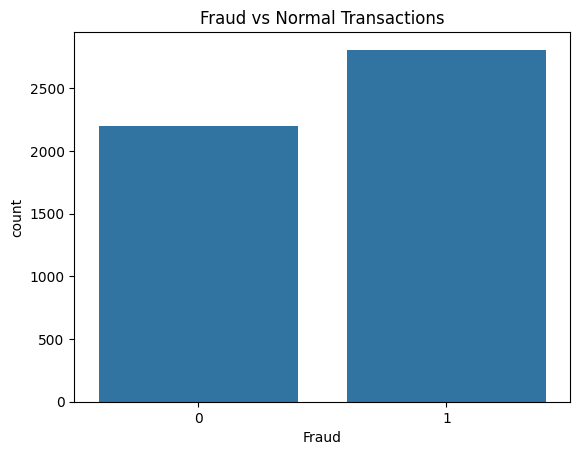

In [144]:
# Combine features + target for plotting
data = X.copy()
data["Fraud"] = y

print(data["Fraud"].value_counts())

sns.countplot(x="Fraud", data=data)
plt.title("Fraud vs Normal Transactions")
plt.show()

In [145]:
# 2️⃣ Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [146]:
# 3️⃣ Train model
model = RandomForestClassifier(class_weight='balanced', random_state=42)
model.fit(X_train, y_train)


RandomForestClassifier(class_weight='balanced', random_state=42)

Model Accuracy: 0.999


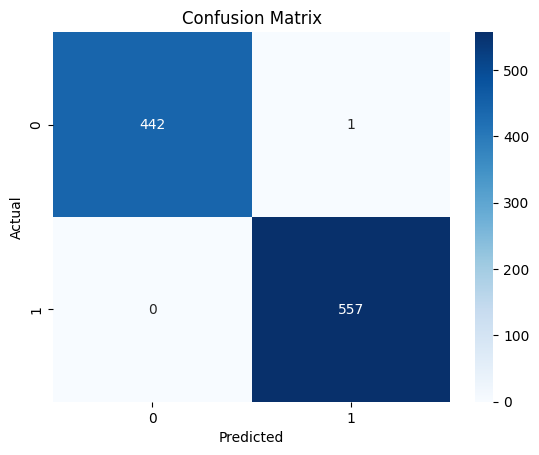

In [147]:
# 4️⃣ Evaluate
predictions = model.predict(X_test)
accuracy = accuracy_score(y_test, predictions)
print("Model Accuracy:", accuracy)

cm = confusion_matrix(y_test, predictions)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [148]:
# 5️⃣ Save model
joblib.dump(model, "fraud_detection_model.pkl")

['fraud_detection_model.pkl']

In [149]:
# 6️⃣ Gradio app
def make_prediction(amount, oldbalance, newbalance):
    input_df = pd.DataFrame([[amount, oldbalance, newbalance]],
                            columns=["amount", "oldbalance", "newbalance"])
    prediction = model.predict(input_df)[0]

    if oldbalance - amount < 0:
        reason = "Transaction causes negative balance"
        status = "⚠️ High Risk"
    elif prediction == 1:
        reason = "Model predicts potential fraud"
        status = "⚠️ High Risk"
    else:
        reason = "Model predicts safe transaction"
        status = "✅ Low Risk"

    output_text = (
        f"{status}\n"
        f"Reason: {reason}\n"
        f"Transaction Amount: {amount}\n"
        f"Old Balance: {oldbalance}\n"
        f"New Balance: {oldbalance - amount}"
    )
    return output_text

In [150]:
# Gradio interface
app = gr.Interface(
    fn=make_prediction,
    inputs=[
        gr.Number(label="Transaction Amount"),
        gr.Number(label="Sender's Old Balance"),
        gr.Number(label="Sender's New Balance")
    ],
    outputs=gr.Textbox(label="Prediction", lines=10),
    title="Fraud Detection AI",
    description="Enter transaction details to check fraud risk and see reason."
)

In [151]:
# Launch Gradio app
app.launch(share=True, inline=False)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://cde6aa2a630a514bc8.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
